# Pairs trading: Engle-Granger cointegration with dynamic pair selection

Universe: crypto pairs, daily bars · Sample: 2022-01-01 → 2026-05-22

**Following on from the static cointegration and rolling-β notebooks**, this version makes *pair selection* dynamic — re-running the EG and half-life screen on a rolling window so the pair set can refresh, while keeping β static within each segment.

**No more train/test split.** Under continuous walk-forward selection, every segment's pairs are fitted on the prior lookback window only. No period was ever used to select itself, so there's no in-sample / out-of-sample distinction. Stats are reported full-sample.

**Selection pipeline.** Every `RESELECT_EVERY_MONTHS` months, re-run two-way Engle-Granger (p < 0.01, max 1 pair per coin) on the trailing `SEL_LOOKBACK_MONTHS` months. Apply the half-life filter (keep 4–20 day mean-reversion speed). The resulting pair set and its EG-fit α/β are held constant for the next segment. Everything else — 180-day z-score, |z|>2.5 entry, |z|<0.5 exit, gross exposure normalised to 1, flat 20 bps and liquidity-aware cost models — match the earlier notebooks.

**A note on warmup.** Trading doesn't start at the beginning of the sample — the first selection can't happen until enough history has accumulated for a meaningful EG fit, so the earliest live date is `data_start + lookback`. Performance stats and benchmark comparison with BTC HODL below are computed from that date onwards, which means longer-lookback configurations have a shorter effective trading window.

## Findings

Net Sharpe improves clearly as the lookback window grows, and a 12-month cadence consistently outperforms a 6-month one. The top configuration overall is **24-month lookback / 12-month cadence** at a net Sharpe of 2.60 — but that comes with a shorter effective trading window and less dynamism. 

Every configuration with at least a 12-month lookback produces a net sharpe above the lower target of 0.5, comfortably above BTC HODL on a risk-adjusted basis. Looking at the 12/12 confirguration as our example, absolute returns are *lower* than BTC, but volatility and drawdown depth are also lower. Matching BTC on absolute return would require leverage, which introduces additional costs and risks. Max drawdown is shallower than BTC, though drawdown duration is comparable.

The static cointegration notebook had an in-sample Sharpe above 7 that flattered the strategy — an artefact of selecting and fitting pairs on the same data the backtest then traded. Continuous walk-forward selection removes that entirely: no period is ever used to choose its own pairs. The stats below are honest in a way the earlier notebooks' in-sample numbers were not.

**Net Sharpe (full sample, 20 bps)**

| Lookback ↓ / Cadence → | 6 | 12 | 24 |
|:--|--:|--:|--:|
| 6  | 0.26 | — | — |
| 12 | 1.22 | 1.75 | — |
| 24 | 1.57 | 2.60 | 2.08 |

**Alpha t-stat (vs BTC, net)**

| Lookback ↓ / Cadence → | 6 | 12 | 24 |
|:--|--:|--:|--:|
| 6  | 0.34 | — | — |
| 12 | 2.36 | 3.50 | — |
| 24 | 2.35 | 3.97 | 3.13 |

**Information ratio (vs BTC, net)**

| Lookback ↓ / Cadence → | 6 | 12 | 24 |
|:--|--:|--:|--:|
| 6  | 0.24 | — | — |
| 12 | 1.51 | 2.36 | — |
| 24 | 1.00 | 2.40 | 1.46 |

*Whilst 24 months lookback, 12 month cadence, gives the best result - this means the trading period for the strategy is shorter and there is limited dynamism. The 12/12 month strategy also delivers strong net results. I note that this strategy now largely removes any overfitting or look-ahead bias that was evident in the training sample for the static configuration.*

In [2]:
# ____ Imports and data loading ____
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import statsmodels.api as sm
# Cointegration-specific: pair enumeration, parallel execution, Engle-Granger test
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from joblib import Parallel, delayed
from statsmodels.tsa.stattools import coint

def read_crypto_data(interval):
    """
    Load cached price and volume pickles for a given timeframe
    interval:
        One of ["1d", "8h", "4h", "1h"] matching saved files.
    """
    path_px = Path(f"data_output/crypto_px_{interval}.pkl")
    path_vol = Path(f"data_output/crypto_vol_{interval}.pkl")
    if not path_px.exists() or not path_vol.exists():
        raise FileNotFoundError(f"Missing pickle files for interval {interval}")
    crypto_px = pd.read_pickle(path_px)
    crypto_vol = pd.read_pickle(path_vol)
    return crypto_px, crypto_vol

In [3]:
# ___ Functions for key stats/turnover/sharpe ____
# Annualisation helper
PERIODS_PER_YEAR = {"1d": 365, "8h": 365*3, "4h": 365*6, "1h": 365*24}

def compute_sharpe(rets,ppy=365):
    mean = rets.mean()*ppy # Crypto trades every day
    vol = rets.std()*np.sqrt(ppy)
    sharpe = mean / vol
    return sharpe

def drawdown(rets):
    cum = (1+rets).cumprod()
    return cum/cum.cummax()  - 1

def max_dd(rets):
    return drawdown(rets).min()

def max_dd_duration(rets):
    dd = drawdown(rets)
    underwater = dd < 0
    groups = (~underwater).cumsum()
    return int(underwater.groupby(groups).cumsum().max())

def compute_keystats(rets, ppy=365):
    rets = rets.dropna()
    if len(rets) == 0:
        return pd.Series({'avg': np.nan, 'vol': np.nan, 'sharpe': np.nan, 
                          'hit_rate': np.nan, 'max_dd': np.nan, 'max_dd_duration': np.nan,
        })
    avg = rets.mean() * ppy
    vol = rets.std() * np.sqrt(ppy)
    sharpe = avg / vol if vol > 0 else np.nan
    hit_rate = (rets > 0).sum() / (rets != 0).sum() if (rets != 0).any() else np.nan
    return pd.Series({'avg': avg, 'vol': vol, 'sharpe': sharpe, 
                      'hit_rate': hit_rate, 'max_dd':max_dd(rets),'max_dd_duration':max_dd_duration(rets)})

def compute_turnover(port):
    to = (port.fillna(0)-port.shift().fillna(0)).abs().sum(1)   
    return to

In [4]:
# ____ Engle-Granger two-way cointegration test for one pair (training data) ____
def adf_for_pair(coin_i, coin_j, train_px):
    # Align both series on common non-NaN, non-zero dates
    paired = train_px[[coin_i, coin_j]].replace(0, np.nan).dropna()
    
    if len(paired) < 60:   # not enough data for a meaningful test
        return (coin_i, coin_j), (1.0, 0.0, 0.0, 1.0)
    
    Y = np.log(paired[coin_i]).values
    X = np.log(paired[coin_j]).values

    try:
        # Test both directions and keep the WORSE p-value — a pair only qualifies if ...
        # ...it's cointegrated whichever coin is the dependent one (conservative)
        # Y on X
        t_stat_1, p_value_1, _ = coint(Y, X)
        # X on Y
        t_stat_2, p_value_2, _ = coint(X, Y)
        p_value = max(p_value_1, p_value_2)
        t_stat  = max(t_stat_1, t_stat_2)
        # Static OLS hedge ratio (log Y on log X) — frozen and reused in the backtest
        model = sm.OLS(Y, sm.add_constant(X)).fit()
        alpha = model.params[0]
        beta  = model.params[1]
    except (ValueError, np.linalg.LinAlgError):
        return (coin_i, coin_j), (1.0, 0.0, 0.0, 1.0)   # fail-safe: p=1 → never selected
    return (coin_i, coin_j), (p_value, t_stat, alpha, beta)

In [5]:
# ____ Half-life of mean reversion filter ___
def compute_half_life(spread):
    """
    Compute the half-life of mean reversion for a spread series.
    Uses the OLS regression: Δz_t = -λ * z_{t-1} + ε
    Half-life = ln(2) / λ
    Returns half-life in bars (days for 1d data).
    Returns np.inf if the series isn't mean-reverting (λ <= 0).
    """
    spread = spread.dropna()
    if len(spread) < 30:
        return np.inf
    
    z_lag = spread.shift(1).dropna()   # yesterday's spread level
    dz = spread.diff().dropna()        # today's change in the spread
    # Align
    z_lag, dz = z_lag.align(dz, join='inner')
    
    if len(z_lag) < 10 or z_lag.var() == 0:
        return np.inf
    # OLS slope of dz on z_lag via cov/var; λ = -slope is the pull-back speed
    beta = np.cov(z_lag, dz, ddof=1)[0, 1] / np.var(z_lag, ddof=1)
    lambda_hat = -beta
    if lambda_hat <= 0:
        return np.inf  # not mean-reverting
    
    return np.log(2) / lambda_hat


def filter_pairs_by_half_life(pairs_df, train_px, max_half_life=30, min_half_life=2):
    """
    Filter pairs_df to keep only those with mean-reversion half-life within bounds.
    Uses the same alpha/beta from pairs_df to construct the spread.
    """
    keep_rows = []
    half_lives = []
    
    for _, row in pairs_df.iterrows():
        coin_i, coin_j = row['coin1'], row['coin2']
        alpha, beta = row['alpha'], row['beta']
        
        # Rebuild the training spread with the frozen hedge ratio
        log_i = np.log(train_px[coin_i].replace(0, np.nan).ffill())
        log_j = np.log(train_px[coin_j].replace(0, np.nan).ffill())
        spread = log_i - beta * log_j - alpha
        
        hl = compute_half_life(spread)
        half_lives.append(hl)
        
        # Keep only pairs that revert on a tradeable horizon
        if min_half_life <= hl <= max_half_life:
            keep_rows.append(row)
    
    filtered = pd.DataFrame(keep_rows).reset_index(drop=True)
    
    print(f"  Half-life filter: {len(pairs_df)} → {len(filtered)} pairs "
          f"(kept {min_half_life} ≤ HL ≤ {max_half_life} days)")
    print(f"  Half-life distribution (all): "
          f"min={min(half_lives):.1f}, median={np.median(half_lives):.1f}, "
          f"max={max([h for h in half_lives if h != np.inf], default=np.inf):.1f}, "
          f"inf={sum(1 for h in half_lives if h == np.inf)}")
    
    return filtered, half_lives

In [6]:
# ____ Full ADF using Parelllel to reduce runtime ___
def adf_full(train_px):
    coins = train_px.columns.tolist()
    pairs = list(combinations(coins,2))
    # Parallel computation of ADF test for all pairs
    adf_results = Parallel(n_jobs=-1)(
        delayed(adf_for_pair)(coin_i, coin_j, train_px) for coin_i, coin_j in pairs)
    pairs, results = zip(*adf_results)
    adf_df = pd.DataFrame(results, columns=['p_value', 'test_statistic','alpha','beta'], index=pairs)
    adf_df = adf_df.sort_values(by='test_statistic')
    return adf_df

In [7]:
# ____ Function to choose pairs of coins based on cointegration ___
def sel_coint_pairs(train_px, sig_level = 0.01, max_pairs_per_coin = 1):
    adf_df = adf_full(train_px)
    qualified_df = adf_df[adf_df['p_value']<sig_level].copy()   # significantly cointegrated only
    if qualified_df.empty:
        return pd.DataFrame(columns=['coin1', 'coin2', 'p_value', 'test_statistic'
                                    ,'alpha','beta'])
    # Sort by most negative t-stat
    qualified_df = qualified_df.sort_values(by='test_statistic')
    # Flatten the pair tuples in the index into two columns
    qualified_df['coin1'] = [pair[0] for pair in qualified_df.index]
    qualified_df['coin2'] = [pair[1] for pair in qualified_df.index]
    qualified_df = qualified_df.reset_index(drop=True)
    
    # Keep each pair only if neither coin has hit its usage cap yet
    # (greedy from strongest down → stops one coin dominating the book)
    used = Counter()
    keep = []
    for _, row in qualified_df.iterrows():
        if used[row.coin1] < max_pairs_per_coin and used[row.coin2] < max_pairs_per_coin:
            keep.append(row)
            used[row.coin1] += 1
            used[row.coin2] += 1          
    pairs_df = pd.DataFrame(keep).reset_index(drop=True)
    pairs_df = pairs_df[['coin1', 'coin2', 'p_value', 'test_statistic','alpha','beta']]
    return pairs_df

In [8]:
# ___ Signal construction (spread → z-score) ___
def build_signals(px, pairs_df, window = 180):
    key_params = {}
    for _,row in pairs_df.iterrows():
        asset_i = row['coin1']
        asset_j = row['coin2']
        alpha = row['alpha']
        beta = row['beta']
        pair = (asset_i, asset_j)

        log_i = np.log(px[asset_i].replace(0, np.nan).ffill())
        log_j = np.log(px[asset_j].replace(0, np.nan).ffill())
        # Spread built with the STATIC hedge ratio, applied across the full series
        resid = log_i - (beta * log_j) - alpha
        # Standardise on a rolling window (rolling z-score, NOT a rolling beta)
        resid_mean = resid.rolling(window=window, min_periods=window//2).mean()
        resid_std = resid.rolling(window=window, min_periods=window//2).std()
        z_score = (resid - resid_mean) / resid_std
        key_params[(pair, 'beta')] = pd.Series(beta, index=px.index)
        key_params[(pair, 'alpha')] = pd.Series(alpha, index=px.index)
        key_params[(pair, 'resid')] = resid
        key_params[(pair, 'z_score')] = z_score
    return pd.DataFrame(key_params)

In [9]:
# ____ Position sizing (z-score → weights) ____
def build_weights(key_params, pairs_df, z_entry = 2.5, z_exit = 0.5):
    """ Convert the pair-level z-scores into per-coin portfolio weights. 
    Then normalise so absolute sum of weights equal to 1"""
    pairs = list(zip(pairs_df['coin1'], pairs_df['coin2']))
    coins = sorted({c for pair in pairs for c in pair})
    raw = pd.DataFrame(index=key_params.index, columns=coins, dtype=float)
    for pair in pairs:
        asset_i, asset_j = pair
        z = key_params[(pair, 'z_score')]
        beta = key_params[(pair, 'beta')]

        # Entries
        raw.loc[z > z_entry,  asset_i] = -1
        raw.loc[z > z_entry,  asset_j] = beta
        raw.loc[z < -z_entry, asset_i] = 1
        raw.loc[z < -z_entry, asset_j] = -beta
        # Exits override entries when |z| is small
        flat = z.abs() < z_exit
        raw.loc[flat, asset_i] = 0
        raw.loc[flat, asset_j] = 0

    # Hold previous position between entry and exit thresholds
    raw = raw.ffill()
    # Normalise per bar so |weights|.sum = 1 (or 0 if all flat)
    pos = raw.divide(raw.abs().sum(axis=1),axis=0).fillna(0)

    return pos

In [10]:
# ___ Backtest formula ____
def backtest(px, pos):
    simple_ret = px.pct_change(fill_method = None)
    cols = [c for c in pos.columns if c in simple_ret.columns]
    port_ret = (pos[cols].shift(1) * simple_ret[cols]).sum(axis=1) # Avoid lookahead bias
    return port_ret

In [11]:
# ____ Main run and stats for different sample periods ____
def run_strategy(px, pairs_df,  window=180, z_entry=2.5, z_exit=0.5):
    """
    Run the full pipeline on a price series and return strategy returns.
    """
    signals = build_signals(px, pairs_df, window=window)
    weights = build_weights(signals, pairs_df,
                            z_entry=z_entry, z_exit=z_exit)
    port_ret = backtest(px, weights)
    return port_ret, weights, signals

## Dynamic pair selection approach

We now re-run the cointegration and half-life screens periodically as the backtest moves forward. Each time, the screen uses only data from the prior **lookback** window — so we never let future information influence which pairs we trade — and the resulting pair set is then held fixed until the next refresh.

Two knobs control how this behaves:

- **Lookback** — how much recent history each re-selection looks at when deciding which pairs are cointegrated. Longer windows are likely to give a more statistically reliable test but adapt more slowly.
- **Cadence** — how often we re-run the selection. More frequent refreshes adapt faster but also increases turnover and reduces net sharpe.

In [12]:
# ===== Dynamic pair selection — static β within each 6-month segment =====
# At each re-selection date, refit EG + half-life on the prior 6 months and
# trade that pair set for the next 6 months with the α/β it produced.

crypto_px, crypto_vol = read_crypto_data("1d")

# Universe: require >=90% coverage across the FULL sample (consistent universe)
coverage = crypto_px.notna().mean()
eligible = coverage[coverage >= 0.90].index
crypto_px  = crypto_px[eligible]
crypto_vol = crypto_vol[eligible]

# --- Dynamic-selection configuration ---
SEL_LOOKBACK_MONTHS   = 12    # rolling lookback used for each EG re-selection
RESELECT_EVERY_MONTHS = 12   # cadence of re-selection (= segment length)
WARMUP_DAYS           = 180   # z-score window — slice needs this much pre-segment data
SIG_LEVEL             = 0.01
MAX_PAIRS_PER_COIN    = 1
MAX_HL                = 20
MIN_HL                = 4
Z_WINDOW              = 180
Z_ENTRY               = 2.5
Z_EXIT                = 0.5

# Build the schedule: first selection happens 6 months in (uses first 6m of data)
data_start = crypto_px.index.min()
data_end   = crypto_px.index.max()
first_segment_start = data_start + pd.DateOffset(months=SEL_LOOKBACK_MONTHS)
selection_dates = pd.date_range(
    start=first_segment_start,
    end=data_end,
    freq=pd.DateOffset(months=RESELECT_EVERY_MONTHS),
)
print(f"Data: {data_start.date()} → {data_end.date()}")
print(f"First selection date: {first_segment_start.date()} (uses {data_start.date()} → {(first_segment_start - pd.Timedelta(days=1)).date()})")
print(f"Re-selection cadence: every {RESELECT_EVERY_MONTHS} months")
print(f"Total segments: {len(selection_dates)}")

Data: 2022-01-01 → 2026-05-22
First selection date: 2023-01-01 (uses 2022-01-01 → 2022-12-31)
Re-selection cadence: every 12 months
Total segments: 4


In [13]:
# Walk forward: at each segment_start, select pairs on the prior 6 months,
# then trade [segment_start, segment_end] with the α/β from that selection.
all_weights = pd.DataFrame(index=crypto_px.index, columns=crypto_px.columns, dtype=float)
selected_pairs_log = {}   # segment_start → pairs_df, for diagnostics later

for i, segment_start in enumerate(selection_dates):
    segment_end = (
        selection_dates[i + 1] - pd.Timedelta(days=1)
        if i + 1 < len(selection_dates) else data_end
    )
    sel_start = segment_start - pd.DateOffset(months=SEL_LOOKBACK_MONTHS)
    sel_end   = segment_start - pd.Timedelta(days=1)

    print(f"\n=== Segment {i}: select [{sel_start.date()} → {sel_end.date()}] "
          f"| trade [{segment_start.date()} → {segment_end.date()}] ===")

    # 1. Cointegration selection on the lookback window
    sel_px = crypto_px.loc[sel_start:sel_end]
    pairs_df = sel_coint_pairs(
        sel_px, sig_level=SIG_LEVEL, max_pairs_per_coin=MAX_PAIRS_PER_COIN
    )
    print(f"  After EG: {len(pairs_df)} pairs")
    if pairs_df.empty:
        print("  Skipping segment (no cointegrated pairs)")
        continue

    # 2. Half-life filter on the same lookback
    pairs_df, _ = filter_pairs_by_half_life(
        pairs_df, sel_px, max_half_life=MAX_HL, min_half_life=MIN_HL
    )
    if pairs_df.empty:
        print("  Skipping segment (no pairs after HL filter)")
        continue

    # 3. Build signals + weights on a slice that includes WARMUP_DAYS of pre-segment
    #    data (so the rolling z-score is valid at segment_start)
    slice_start = segment_start - pd.Timedelta(days=WARMUP_DAYS)
    slice_px = crypto_px.loc[slice_start:segment_end]
    _, weights_seg, _ = run_strategy(
        slice_px, pairs_df,
        window=Z_WINDOW, z_entry=Z_ENTRY, z_exit=Z_EXIT,
    )

    # 4. Splice this segment's weights into all_weights (segment range only)
    for col in weights_seg.columns:
        if col in all_weights.columns:
            all_weights.loc[segment_start:segment_end, col] = (
                weights_seg.loc[segment_start:segment_end, col]
            )

    selected_pairs_log[segment_start] = pairs_df

all_weights = all_weights.fillna(0)
print(f"\nWalk-forward complete. Segments traded: {len(selected_pairs_log)} / {len(selection_dates)}")


=== Segment 0: select [2022-01-01 → 2022-12-31] | trade [2023-01-01 → 2023-12-31] ===
  After EG: 64 pairs
  Half-life filter: 64 → 46 pairs (kept 4 ≤ HL ≤ 20 days)
  Half-life distribution (all): min=1.6, median=5.4, max=14.1, inf=0

=== Segment 1: select [2023-01-01 → 2023-12-31] | trade [2024-01-01 → 2024-12-31] ===
  After EG: 63 pairs
  Half-life filter: 63 → 54 pairs (kept 4 ≤ HL ≤ 20 days)
  Half-life distribution (all): min=2.9, median=5.8, max=23.5, inf=0

=== Segment 2: select [2024-01-01 → 2024-12-31] | trade [2025-01-01 → 2025-12-31] ===
  After EG: 54 pairs
  Half-life filter: 54 → 47 pairs (kept 4 ≤ HL ≤ 20 days)
  Half-life distribution (all): min=3.1, median=5.8, max=22.6, inf=0

=== Segment 3: select [2025-01-01 → 2025-12-31] | trade [2026-01-01 → 2026-05-22] ===
  After EG: 56 pairs
  Half-life filter: 56 → 44 pairs (kept 4 ≤ HL ≤ 20 days)
  Half-life distribution (all): min=2.7, median=6.1, max=16.9, inf=0

Walk-forward complete. Segments traded: 4 / 4



Full-sample stats (gross of fees):
                   strategy    btc_hodl
avg                0.362779    0.581125
vol                0.175303    0.472681
sharpe             2.069436    1.229423
hit_rate           0.545380    0.508170
max_dd            -0.105321   -0.495343
max_dd_duration  160.000000  237.000000


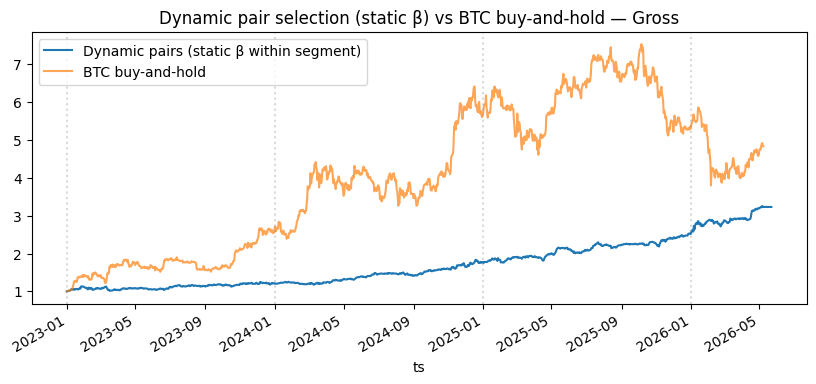

In [14]:
# Backtest the spliced weights, compare to BTC, plot equity with re-selection markers
weights  = all_weights                       # so net/diagnostic cells keep working unchanged
port_ret = backtest(crypto_px, weights)

# Strategy doesn't trade until first_segment_start — trim both series to the live period
live_start = first_segment_start
port_ret   = port_ret.loc[live_start:]
btc_ret    = crypto_px['BTC/USDT'].pct_change(fill_method=None).loc[live_start:].dropna()
btc_full   = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')

stats    = compute_keystats(port_ret, ppy=365).rename('strategy')
combined = pd.concat([stats, btc_full], axis=1)
print("\nFull-sample stats (gross of fees):")
print(combined)

equity     = (1 + port_ret).cumprod()
btc_equity = (1 + btc_ret).cumprod()
ax = equity.plot(figsize=(10, 4), label='Dynamic pairs (static β within segment)')
btc_equity.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
for d in selection_dates:                    # thin grey lines mark each re-selection
    ax.axvline(d, color='grey', linestyle=':', alpha=0.3)
ax.set_title("Dynamic pair selection (static β) vs BTC buy-and-hold — Gross")
ax.legend()
plt.show()

Turnover is 0.07931972400743292
Corresponding holding period is 25.21440946784665

Full-sample stats (net of 20bps):
                   strategy    btc_hodl
avg                0.304876    0.581125
vol                0.174494    0.472681
sharpe             1.747201    1.229423
hit_rate           0.533442    0.508170
max_dd            -0.111809   -0.495343
max_dd_duration  167.000000  237.000000


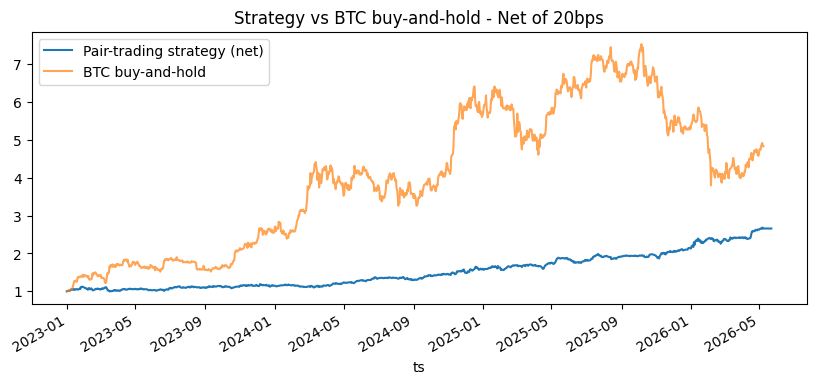

In [15]:
# ____ Net returns (based on 20bps) + stats ____
tcost_bps = 20  # 20 bps for market orders (commissions + slippage)
to = compute_turnover(weights).reindex(port_ret.index).fillna(0)
turnover = to.mean()
holding_period = 2/turnover
port_ret_net = port_ret.subtract(to * tcost_bps * 1e-4, fill_value=0)
print(f"Turnover is {turnover}")
print(f"Corresponding holding period is {holding_period}")
# ---------- Stats ----------
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
stats_net    = compute_keystats(port_ret_net, ppy=365).rename('strategy')
combined_net = pd.concat([stats_net, btc_full], axis=1)
print(f"\nFull-sample stats (net of {tcost_bps}bps):")
print(combined_net)

equity_net = (1 + port_ret_net).cumprod()
btc_equity = (1 + btc_ret).cumprod()
ax = equity_net.plot(figsize=(10, 4), label='Pair-trading strategy (net)')
btc_equity.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.set_title(f"Strategy vs BTC buy-and-hold - Net of {tcost_bps}bps")
ax.legend()
plt.show()

In [18]:
# ===== Scenario sweep: dynamic pair selection (lookback × cadence) =====
# Six configurations where lookback >= cadence (otherwise selection windows
# leave gaps in the data). All other parameters identical to the main run.

import io, contextlib, time

def run_dynamic_config(lookback_months, cadence_months,
                       z_window=180, warmup_days=180,
                       sig_level=0.01, max_pairs_per_coin=1,
                       max_hl=20, min_hl=4,
                       z_entry=2.5, z_exit=0.5,
                       tcost_bps=20):
    """One full walk-forward run for given (lookback, cadence). Returns one stats row."""
    data_start = crypto_px.index.min()
    data_end   = crypto_px.index.max()
    first_segment_start = data_start + pd.DateOffset(months=lookback_months)
    selection_dates = pd.date_range(
        start=first_segment_start, end=data_end,
        freq=pd.DateOffset(months=cadence_months),
    )

    weights = pd.DataFrame(index=crypto_px.index, columns=crypto_px.columns, dtype=float)

    for i, segment_start in enumerate(selection_dates):
        segment_end = (
            selection_dates[i+1] - pd.Timedelta(days=1)
            if i + 1 < len(selection_dates) else data_end
        )
        sel_end   = segment_start - pd.Timedelta(days=1)
        sel_start = sel_end - pd.DateOffset(months=lookback_months) + pd.Timedelta(days=1)

        sel_px   = crypto_px.loc[sel_start:sel_end]
        pairs_df = sel_coint_pairs(sel_px, sig_level=sig_level,
                                   max_pairs_per_coin=max_pairs_per_coin)
        if pairs_df.empty:
            continue
        # Suppress half-life filter's verbose prints (otherwise the sweep is unreadable)
        with contextlib.redirect_stdout(io.StringIO()):
            pairs_df, _ = filter_pairs_by_half_life(
                pairs_df, sel_px, max_half_life=max_hl, min_half_life=min_hl
            )
        if pairs_df.empty:
            continue

        slice_start = segment_start - pd.Timedelta(days=warmup_days)
        slice_px    = crypto_px.loc[slice_start:segment_end]
        _, weights_seg, _ = run_strategy(
            slice_px, pairs_df,
            window=z_window, z_entry=z_entry, z_exit=z_exit,
        )

        weights_mask     = (weights.index     >= segment_start) & (weights.index     <= segment_end)
        weights_seg_mask = (weights_seg.index >= segment_start) & (weights_seg.index <= segment_end)
        cols             = weights_seg.columns.intersection(weights.columns)
        weights.loc[weights_mask, cols] = weights_seg.loc[weights_seg_mask, cols].values

    weights  = weights.fillna(0)
    port_ret = backtest(crypto_px, weights)

    # Trim to live period (no zeros from pre-first-segment dragging stats around)
    port_ret      = port_ret.loc[first_segment_start:]
    btc_ret_local = crypto_px['BTC/USDT'].pct_change(fill_method=None).loc[first_segment_start:].dropna()

    # Flat 20 bps net
    to_series    = compute_turnover(weights)
    port_ret_net = port_ret.subtract(
        to_series.reindex(port_ret.index) * tcost_bps * 1e-4, fill_value=0
    )

    stats = compute_keystats(port_ret_net, ppy=365)
    ab, _ = alpha_beta_block(port_ret_net, btc_ret_local, 'net')

    return {
        'lookback':    lookback_months,
        'cadence':     cadence_months,
        'sharpe':      stats['sharpe'],
        'return':      stats['avg'],
        'vol':         stats['vol'],
        'maxDD':       stats['max_dd'],
        'DDdur':       stats['max_dd_duration'],
        'turnover':    to_series.mean(),
        'alpha_tstat': ab['alpha_tstat'],
        'IR':          ab['ir'],
    }


configs = [
    (6,  6),
    (12, 6),  (12, 12),
    (24, 6),  (24, 12),  (24, 24),
]

sweep_rows = []
for L, C in configs:
    t0 = time.time()
    print(f"--- Running lookback={L}m, cadence={C}m ---")
    row = run_dynamic_config(L, C)
    print(f"    done in {time.time()-t0:.1f}s | Sharpe = {row['sharpe']:.2f}")
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows).set_index(['lookback', 'cadence'])
print("\n=== Dynamic pairs sensitivity (net of 20 bps) ===")
print(sweep_df.round(3))

--- Running lookback=6m, cadence=6m ---
    done in 556.9s | Sharpe = 0.26
--- Running lookback=12m, cadence=6m ---
    done in 986.2s | Sharpe = 1.22
--- Running lookback=12m, cadence=12m ---
    done in 11654.8s | Sharpe = 1.75
--- Running lookback=24m, cadence=6m ---
    done in 83960.1s | Sharpe = 1.57
--- Running lookback=24m, cadence=12m ---
    done in 3564.1s | Sharpe = 2.59
--- Running lookback=24m, cadence=24m ---
    done in 341.3s | Sharpe = 2.08

=== Dynamic pairs sensitivity (net of 20 bps) ===
                  sharpe  return    vol  maxDD  DDdur  turnover  alpha_tstat  \
lookback cadence                                                               
6        6         0.262   0.104  0.398 -0.558  742.0     0.080        0.339   
12       6         1.216   0.240  0.198 -0.196  201.0     0.070        2.360   
         12        1.747   0.305  0.174 -0.112  167.0     0.061        3.497   
24       6         1.567   0.317  0.202 -0.244  305.0     0.049        2.348   
      

In [19]:
# ____ BM-adjusted performance vs BTC ___
def alpha_beta_block(strat_ret, btc_ret, label, ppy=365, roll_window=365, hac_lags=5):
    """Compute beta, alpha, alpha t-stat, IR"""
    df = pd.concat([strat_ret.rename('strat'), btc_ret.rename('btc')], axis=1).dropna()

    # Rolling PIT beta + residuals
    corr = df['strat'].rolling(roll_window).corr(df['btc'])
    vol_s = df['strat'].rolling(roll_window).std()
    vol_b = df['btc'].rolling(roll_window).std()
    beta_roll = corr * vol_s / vol_b
    resid = df['strat'] - beta_roll * df['btc']
    ir = resid.mean() / resid.std() * np.sqrt(ppy) if resid.std() > 0 else np.nan

    # Full-sample OLS for alpha + t-stat
    X = sm.add_constant(df['btc'])
    model = sm.OLS(df['strat'], X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
    alpha_ann   = model.params['const'] * ppy
    beta_full   = model.params['btc']
    alpha_tstat = model.tvalues['const']
    stats = pd.Series({'beta_OLM': beta_full, 'alpha_ann':   alpha_ann, 'alpha_tstat': alpha_tstat,
        'ir':ir,}, name=label)
    return stats, resid

# Apply to gross and net
gross_ab, gross_resid = alpha_beta_block(port_ret, btc_ret, 'gross')
net_ab, net_resid   = alpha_beta_block(port_ret_net, btc_ret, 'net')

ab_table = pd.concat([gross_ab, net_ab], axis=1)
print("\nAlpha/Beta/IR vs BTC:")
print(ab_table)

corr_df = pd.concat([
    net_resid.rename('resid_net'),
    btc_ret.rename('btc'),
], axis=1).dropna()
print("Correlation of resids with BTC matrix:")
print(corr_df.corr().round(3))


Alpha/Beta/IR vs BTC:
                gross       net
beta_OLM    -0.012660 -0.012207
alpha_ann    0.372804  0.314392
alpha_tstat  4.101683  3.496905
ir           2.700203  2.356014
Correlation of resids with BTC matrix:
           resid_net    btc
resid_net      1.000  0.073
btc            0.073  1.000


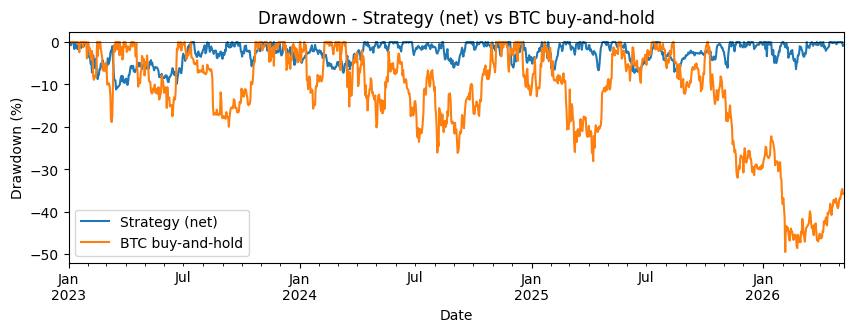

Max drawdown - Strategy (net):   -11.18%
Max drawdown - BTC buy-and-hold: -49.53%


In [20]:
# ___ Drawdown: Strategy (net) vs BTC buy-and-hold ___
comb_ret = pd.concat([
    port_ret_net.rename('strat_ret'),
    btc_ret.rename('buy_and_hold_btc'),
], axis=1).dropna()

dd = drawdown(comb_ret) * 100

plt.figure(figsize=(10, 3))
dd.plot(ax=plt.gca())
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Drawdown - Strategy (net) vs BTC buy-and-hold')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend(['Strategy (net)', 'BTC buy-and-hold'])
plt.show()
print(f"Max drawdown - Strategy (net):   {dd['strat_ret'].min():.2f}%")
print(f"Max drawdown - BTC buy-and-hold: {dd['buy_and_hold_btc'].min():.2f}%")

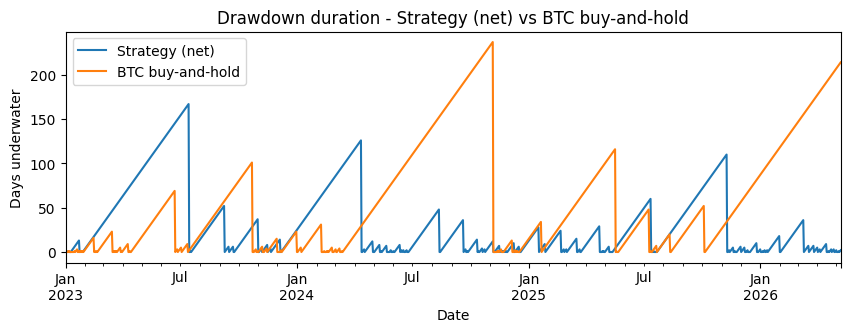

Max drawdown duration - Strategy (net):   167 days
Max drawdown duration - BTC buy-and-hold: 237 days


In [21]:
# ___ Drawdown duration: Strategy (net) vs BTC buy-and-hold ___
def drawdown_duration(rets):
    dd = drawdown(rets)
    underwater = dd < 0
    groups = (~underwater).cumsum()
    return underwater.groupby(groups).cumsum()

ddd = comb_ret.apply(drawdown_duration)

plt.figure(figsize=(10, 3))
ddd.plot(ax=plt.gca())
plt.title('Drawdown duration - Strategy (net) vs BTC buy-and-hold')
plt.xlabel('Date')
plt.ylabel('Days underwater')
plt.legend(['Strategy (net)', 'BTC buy-and-hold'])
plt.show()

print(f"Max drawdown duration - Strategy (net):   {int(ddd['strat_ret'].max())} days")
print(f"Max drawdown duration - BTC buy-and-hold: {int(ddd['buy_and_hold_btc'].max())} days")

In [23]:
# Gross exposure should be ~1.0 every day (or 0 when fully flat)
gross = weights.abs().sum(axis=1)
print("\nGross exposure stats:")
print(gross.describe())
print(f"\nDays with gross == 0 (fully flat): {(gross == 0).sum()}")
print(f"Days with gross ~= 1: {((gross > 0.99) & (gross < 1.01)).sum()}")


Gross exposure stats:
count    1598.000000
mean        0.771589
std         0.419940
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64

Days with gross == 0 (fully flat): 365
Days with gross ~= 1: 1233


In [24]:
# ____ Net returns — liquidity-aware cost model ___
def compute_liquidity_aware_costs(weights, crypto_px, crypto_vol,
                                   high_liquidity_threshold_usd=10_000_000,
                                   slow_bps=7, fast_bps=20,
                                   rolling_days=30):
    w = weights.fillna(0)
    pos_change = (w - w.shift().fillna(0)).abs()
    dollar_vol = crypto_px * crypto_vol
    rolling_dvol = dollar_vol.rolling(rolling_days, min_periods=5).mean()
    common_cols = [c for c in pos_change.columns if c in rolling_dvol.columns]
    pos_change = pos_change[common_cols]
    rolling_dvol = rolling_dvol[common_cols].reindex(pos_change.index)
    bps = pd.DataFrame(
        np.where(rolling_dvol >= high_liquidity_threshold_usd, slow_bps, fast_bps),
        index=pos_change.index, columns=pos_change.columns,
    )
    daily_costs = (pos_change * bps * 1e-4).sum(axis=1).fillna(0)
    return daily_costs

Turnover is 0.06120226514465881
Corresponding holding period is 32.67852905889615

Full-sample stats (net of 20bps):
                   strategy    btc_hodl
avg                0.241609    0.581125
vol                0.153500    0.472681
sharpe             1.574006    1.229423
hit_rate           0.535073    0.508170
max_dd            -0.110834   -0.495343
max_dd_duration  166.000000  237.000000


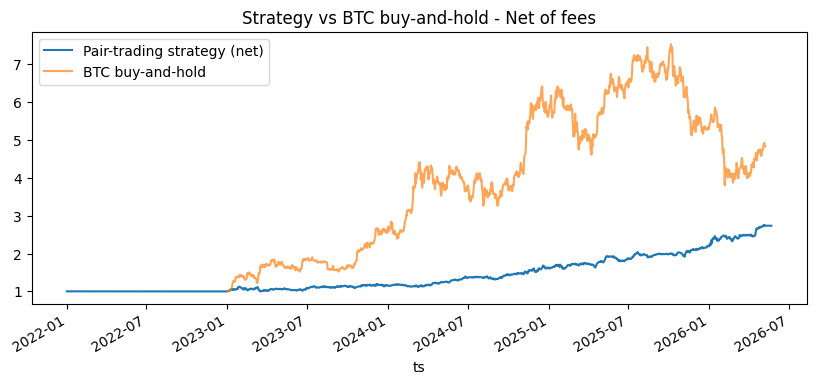

In [25]:
# ____ Net returns (with liquidity aware) + stats ____
daily_costs = compute_liquidity_aware_costs(weights, crypto_px, crypto_vol)
to = compute_turnover(weights)
turnover = to.mean()
holding_period = 2/turnover
port_ret_net = port_ret.subtract(daily_costs, fill_value=0)
print(f"Turnover is {turnover}")
print(f"Corresponding holding period is {holding_period}")

# ---------- Stats ----------
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
stats_net    = compute_keystats(port_ret_net, ppy=365).rename('strategy')
combined_net = pd.concat([stats_net, btc_full], axis=1)
print(f"\nFull-sample stats (net of {tcost_bps}bps):")
print(combined_net)

perf_net = (1 + port_ret_net).cumprod()
btc_perf = (1 + btc_ret).cumprod()
ax = perf_net.plot(figsize=(10, 4), label='Pair-trading strategy (net)')
btc_perf.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.set_title(f"Strategy vs BTC buy-and-hold - Net of fees")
ax.legend()
plt.show()